In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

torch.set_default_dtype(torch.float32)

LOAD DATASET

In [3]:
df=pd.read_csv('train.csv')
#9 inputs 19 outputs
X_train=np.array(df.iloc[:,:9])
y_train=np.array(df.iloc[:,9:])

X_train_t=torch.tensor(X_train)
y_train_t=torch.tensor(y_train)

df=pd.read_csv('test.csv')

X_test=np.array(df.iloc[:,:9])
y_test=np.array(df.iloc[:,9:])

X_test_t=torch.tensor(X_test)
y_test_t=torch.tensor(y_test)
names=df.columns

n_inputs=X_train.shape[1]
n_outputs=y_train.shape[1]

input_names=names[:9]
output_names=names[9:]

PLOTTING

In [ ]:
for i in range(y_train.shape[1]):  
    fig, ax= plt.subplots(1,X_train.shape[1],figsize=(15,5))
    plt.title(f'{output_names[i]}',loc='left')
    for j in range(X_train.shape[1]):
        ax[j].scatter(X_train[:,j],y_train[:,i],marker='.')
        ax[j].set_xlabel(input_names[j])

plt.show()

MULTILINEAR REGRESSION

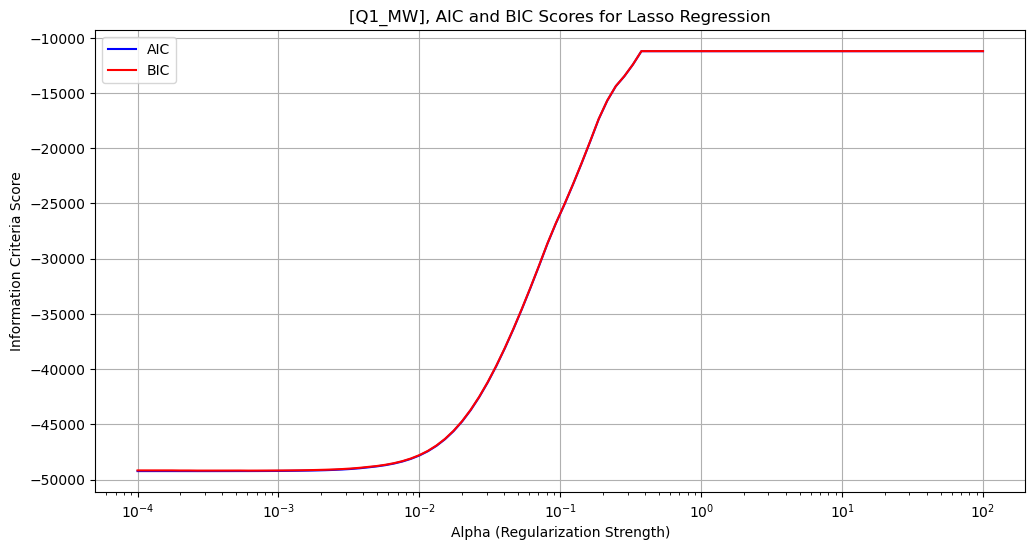

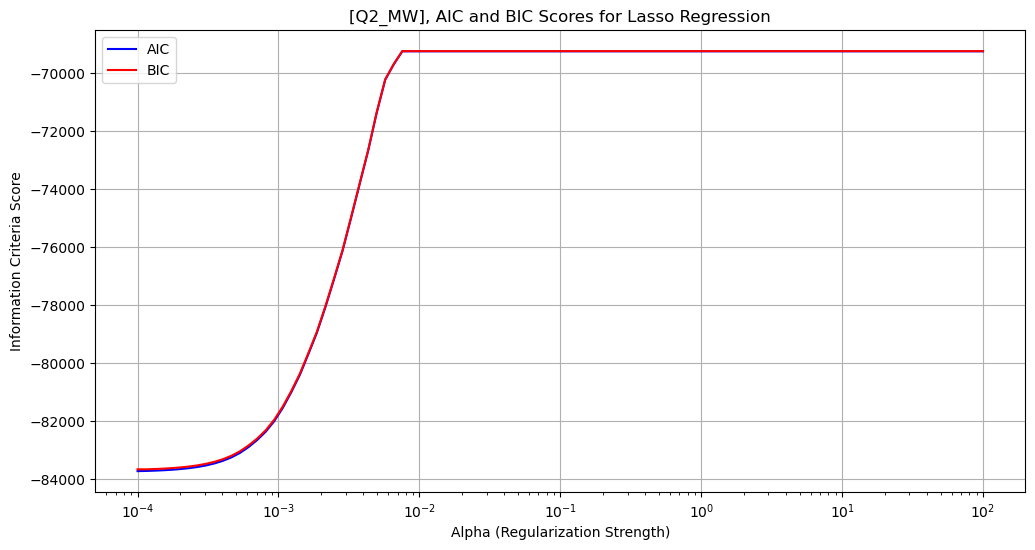

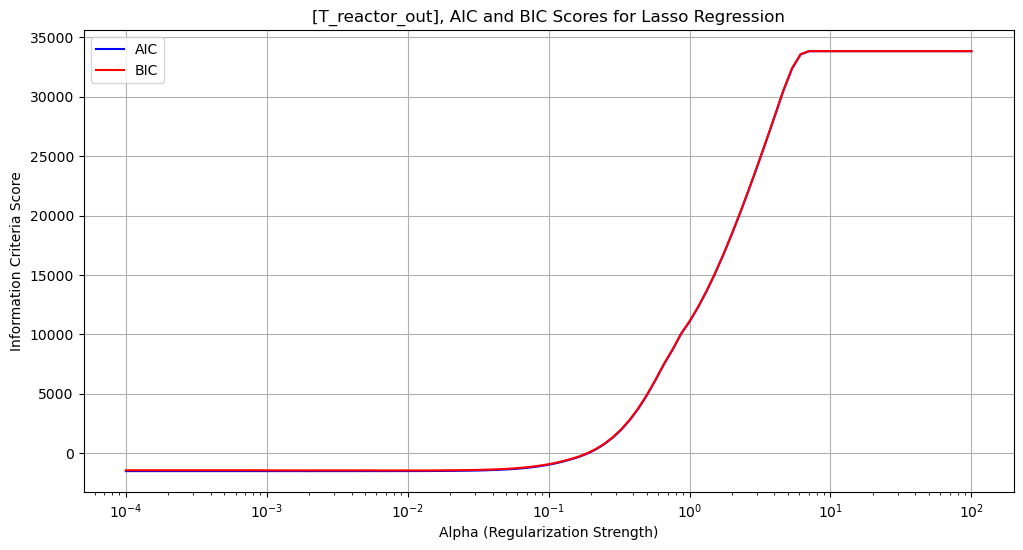

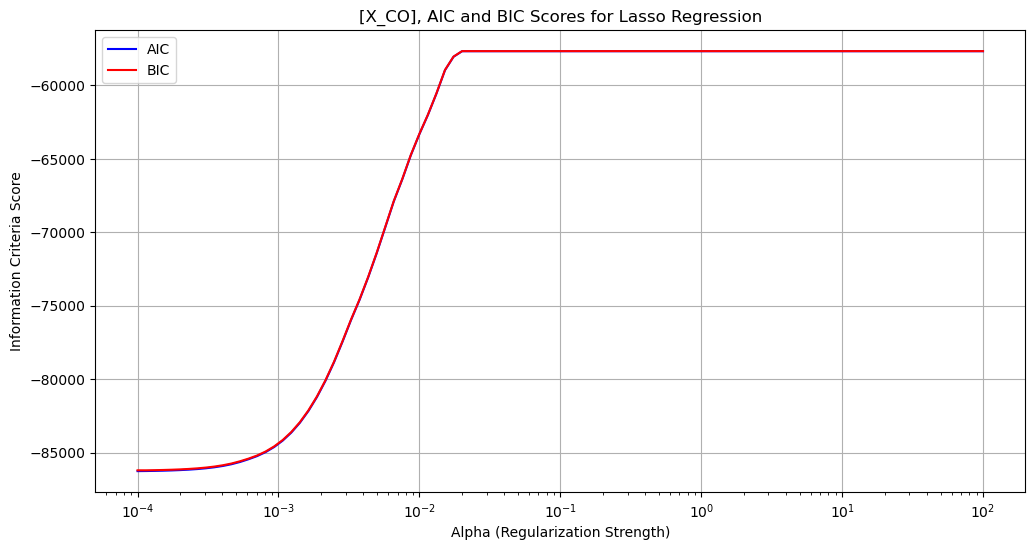

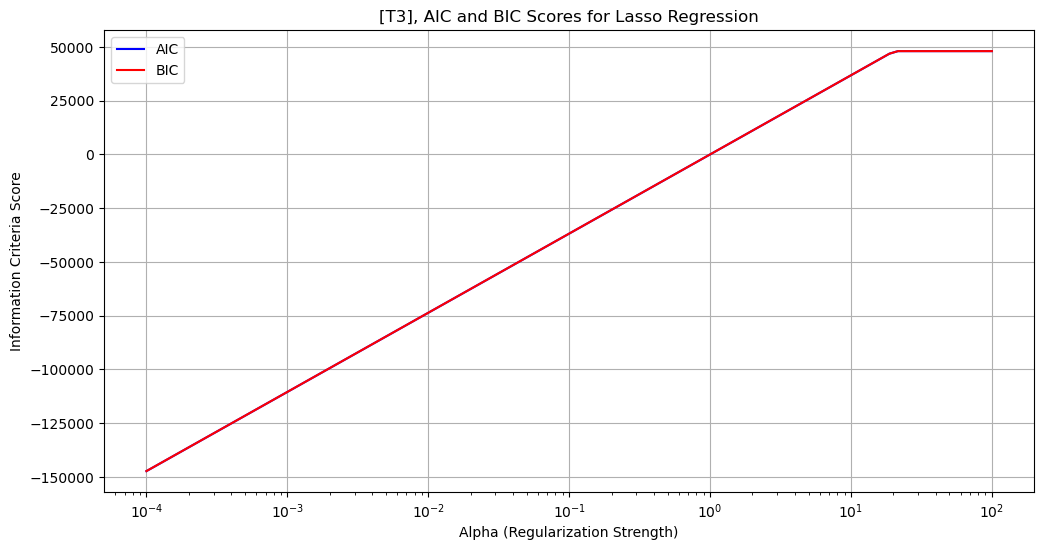

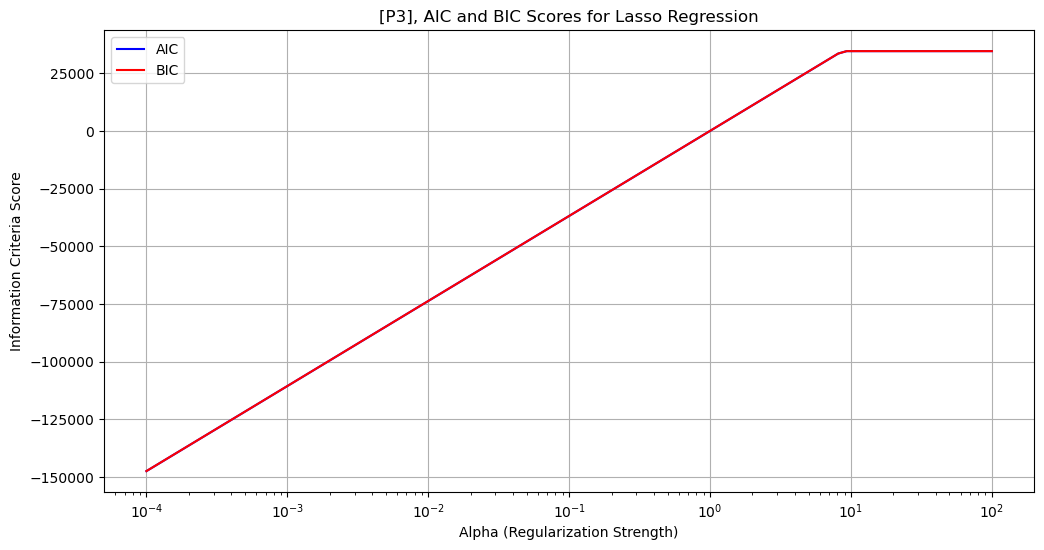

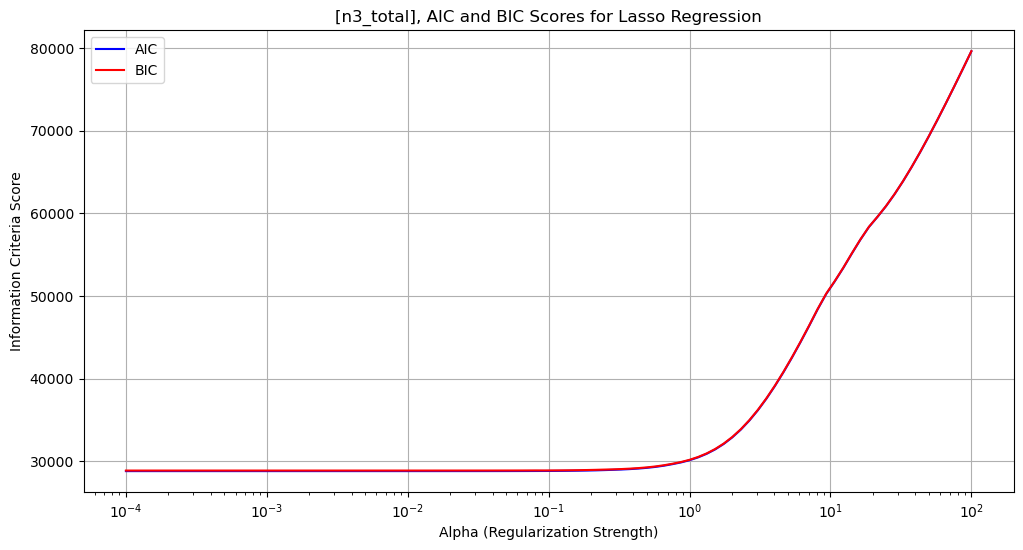

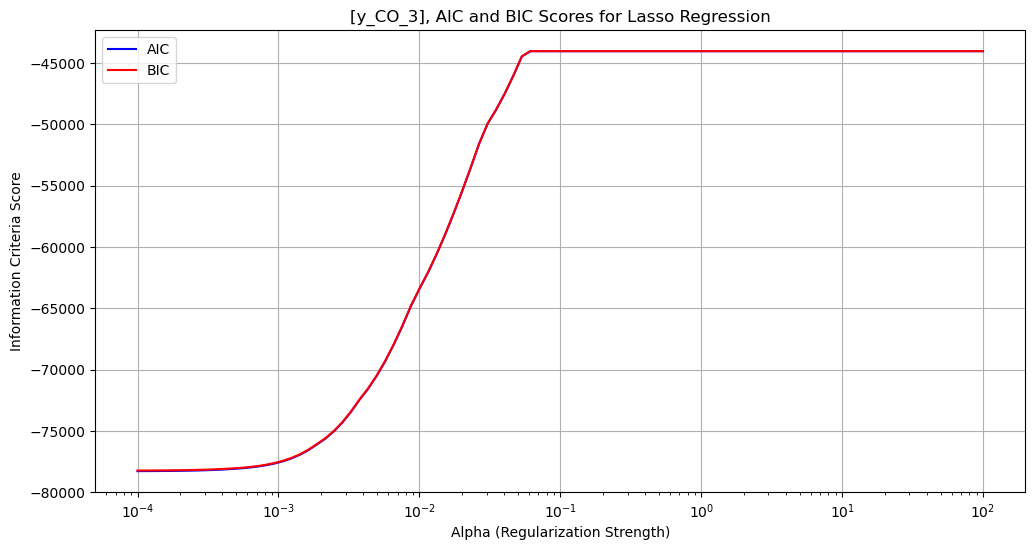

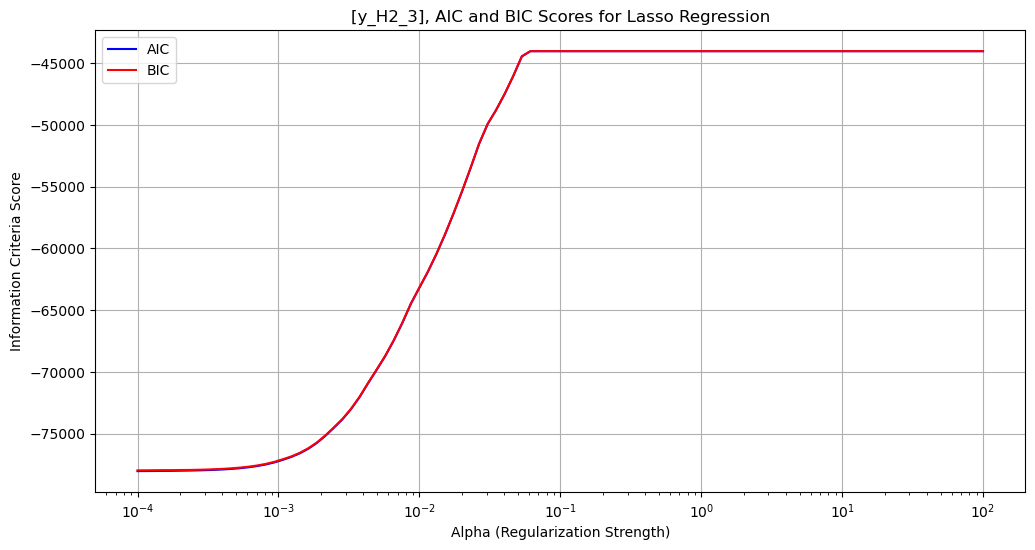

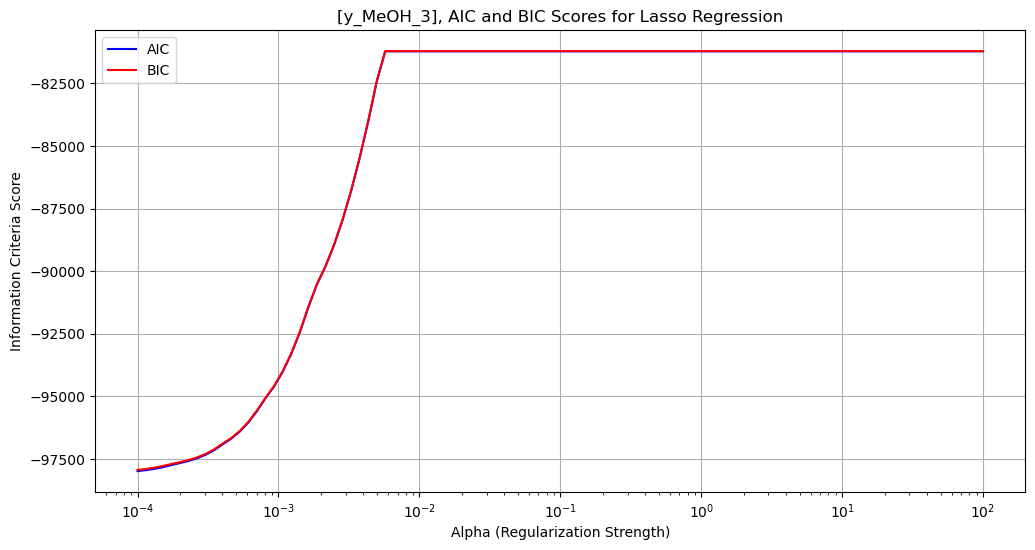

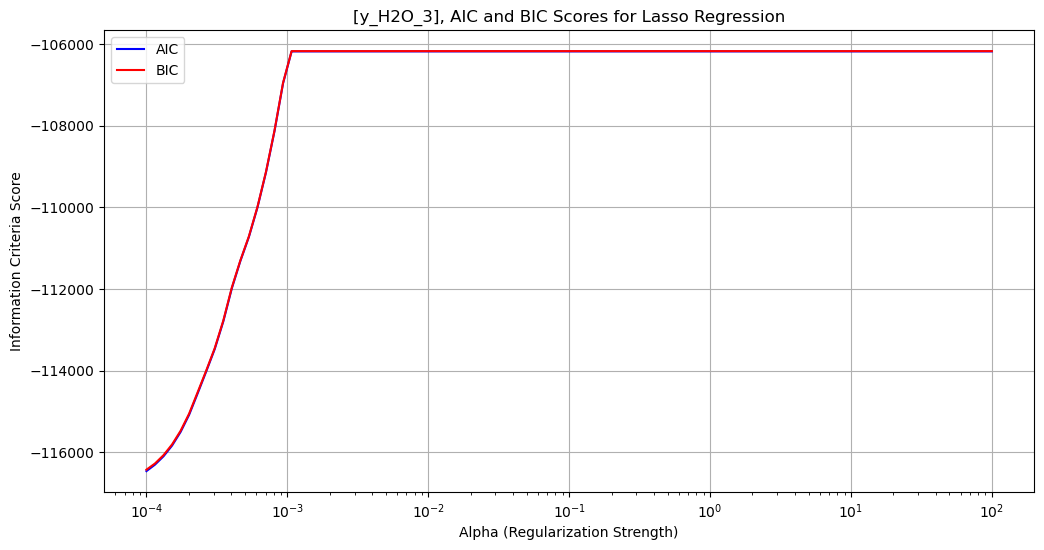

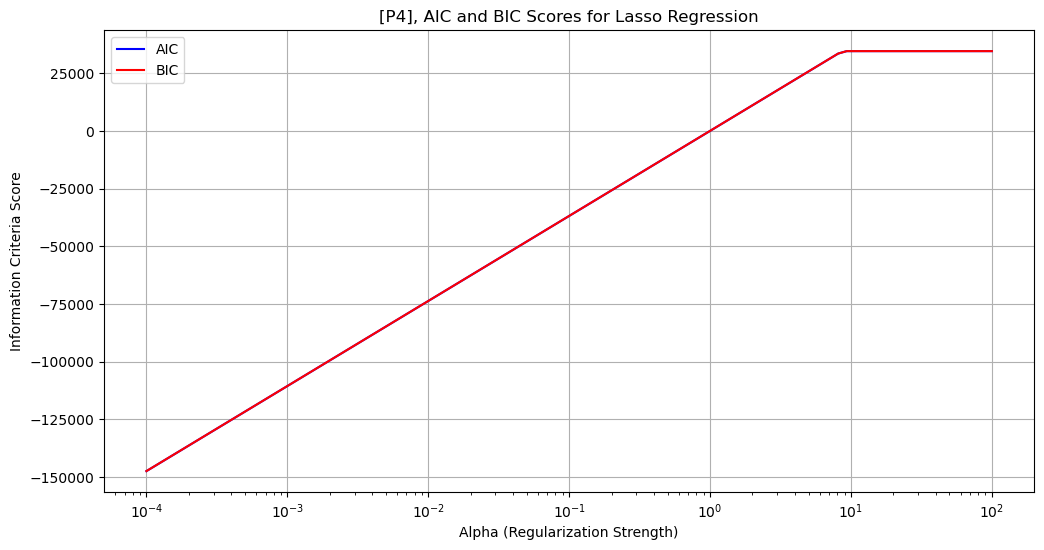

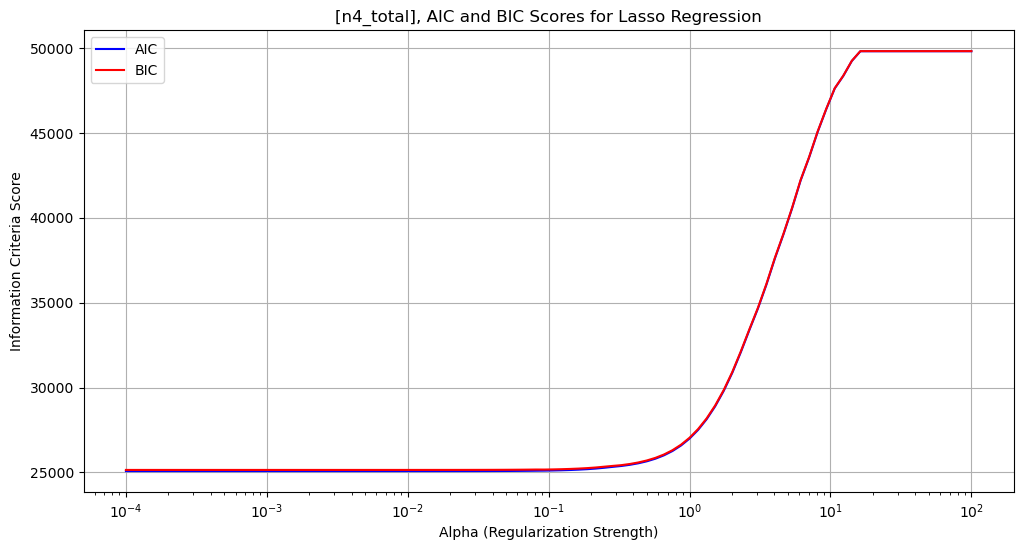

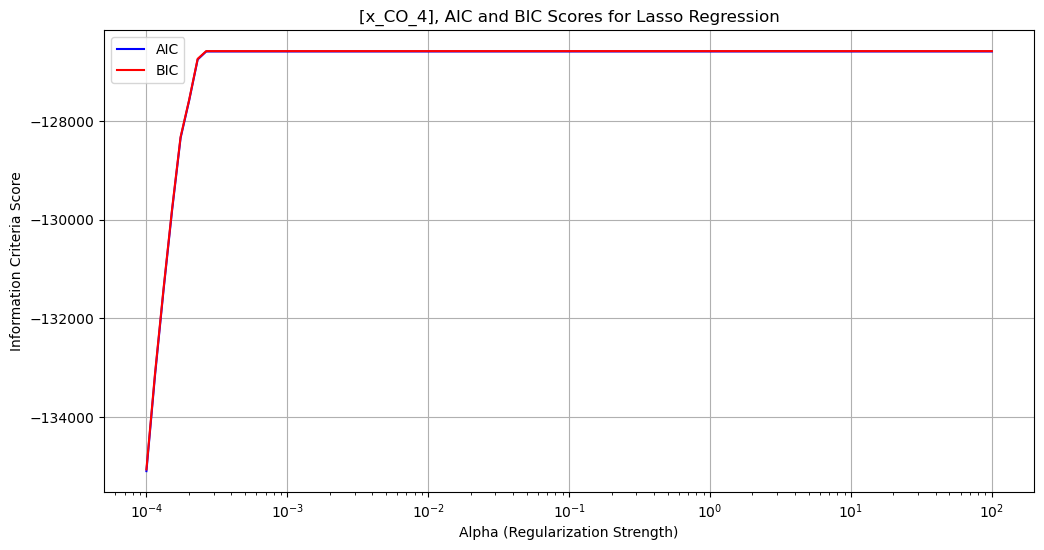

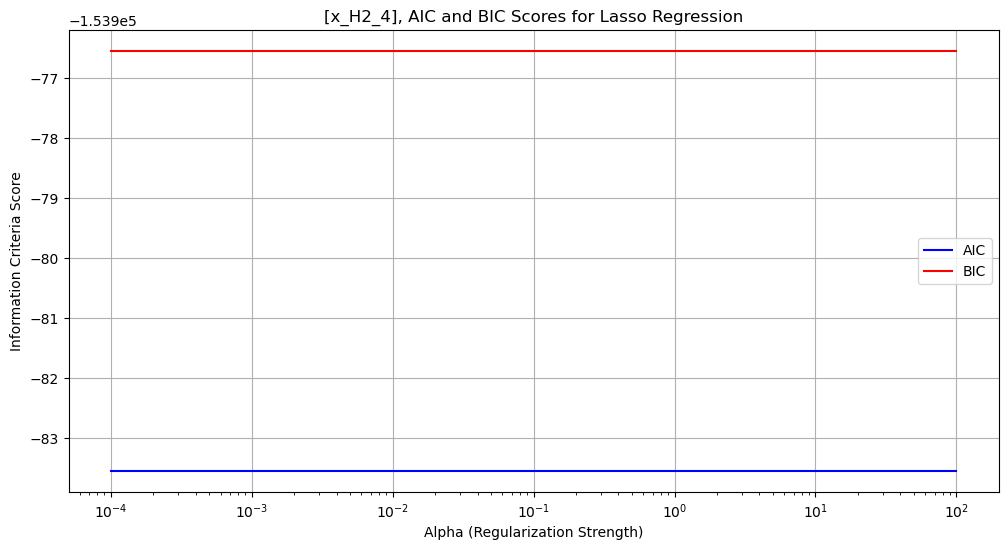

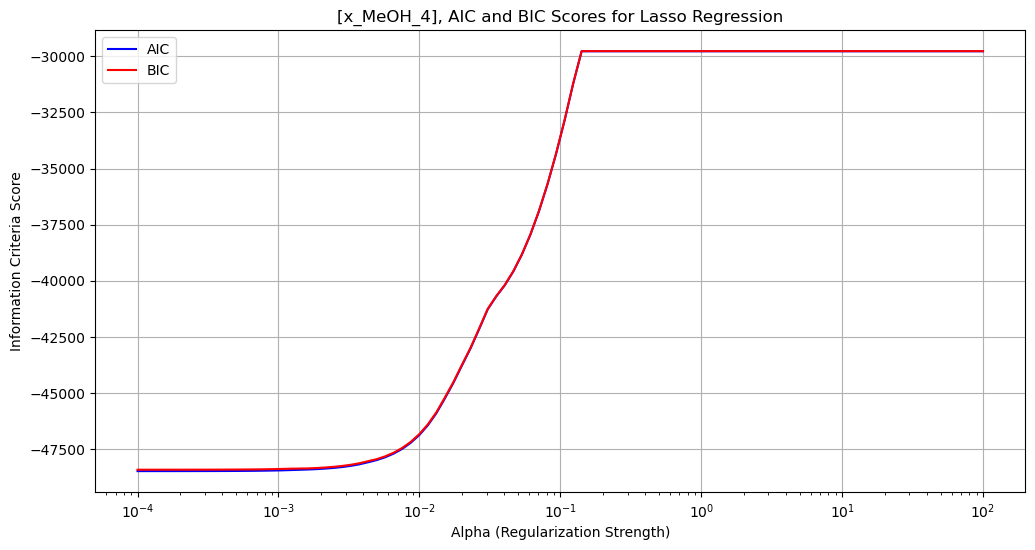

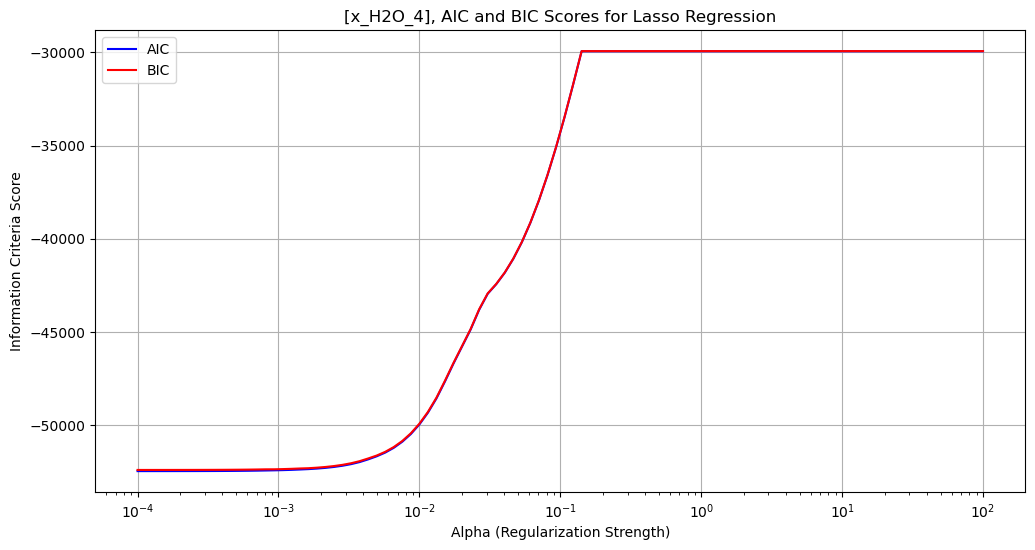

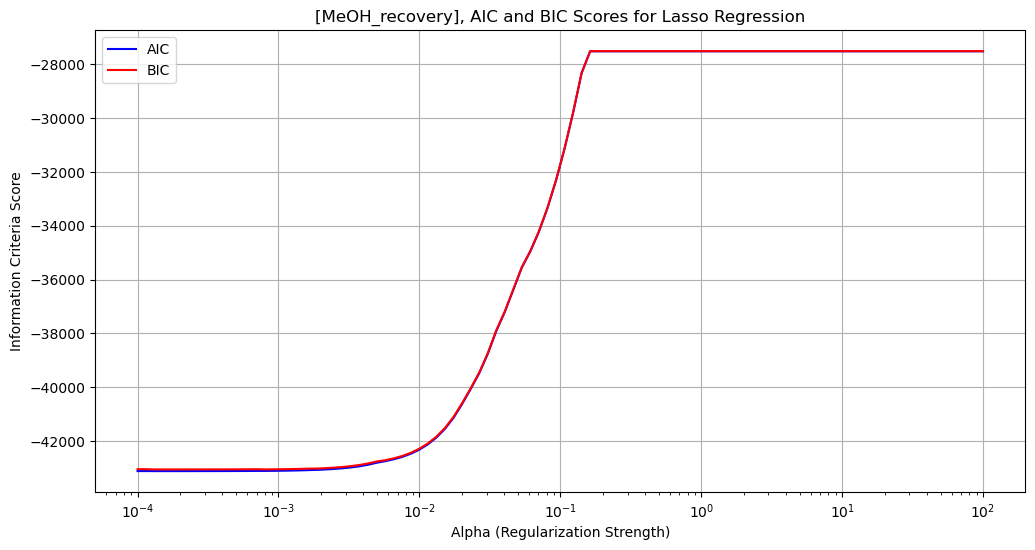

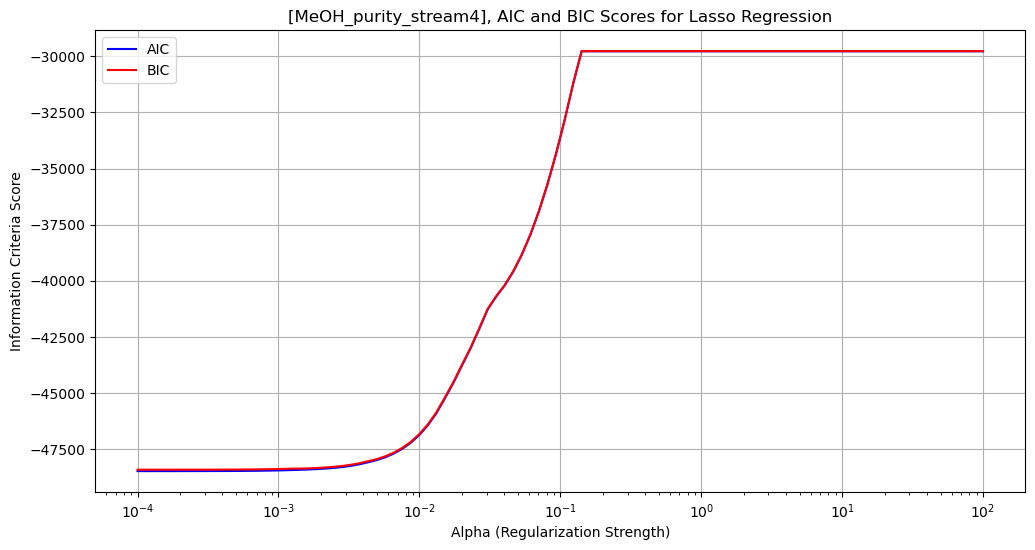

"\nalpha=1e-3\n\nlasso=Lasso(alpha=alpha)\nlasso.fit(X_train_n,y_train[:,0])\ncoefficients=lasso.coef_\nprint(coefficients)\ny_pred=lasso.predict(X_train_n)\n\n\n\nfig,ax =plt.subplots(1,2)\n\nax[0].scatter(y_train[:,0],y_pred,marker='.')\nax[0].set_xlabel('True Values')\nax[0].set_ylabel('Predicted Values')\nplt.show()\n"

In [ ]:
X_avg=np.mean(X_train,axis=0)
X_std=np.std(X_train,axis=0)
X_train_n=(X_train-X_avg)/X_std

def AIC(y_true, y_pred, k):
    # AIC = n * log(RSS/n) + 2k
    n = len(y_true)
    rss = ((y_true - y_pred) ** 2).sum()
    return n * np.log(rss / n) + 2 * k

def BIC(y_true, y_pred, k):
    # BIC = n * log(RSS/n) + k * log(n)
    n = len(y_true)
    rss = ((y_true - y_pred) ** 2).sum()
    return n * np.log(rss / n) + k * np.log(n)


alphas = np.logspace(-4, 2, 100)
for i,output in enumerate(output_names):
    scores_aic = []
    scores_bic = []
    for alpha in alphas:
        lasso = Lasso(alpha=alpha)
        lasso.fit(X_train_n, y_train[:,i])
        y_pred = lasso.predict(X_train_n)
        k = np.sum(lasso.coef_ != 0) + 1  # non-zero features + intercept
        scores_aic.append(AIC(y_train[:,i], y_pred, k))
        scores_bic.append(BIC(y_train[:,i], y_pred, k))
        
    plt.figure(i,figsize=(12, 6))
    plt.plot(alphas, scores_aic, label='AIC', color='blue')
    plt.plot(alphas, scores_bic, label='BIC', color='red')
    #plt.plot(alphas, np.sqrt([scores_aic[j] * scores_bic[j] for j in range(len(alphas))]),
    #     label='Geometric Mean (AIC*BIC)^0.5', color='green')
    plt.xscale('log')
    plt.xlabel('Alpha (Regularization Strength)')
    plt.ylabel('Information Criteria Score')
    plt.title(f'[{output}], AIC and BIC Scores for Lasso Regression')
    plt.legend()
    plt.grid()
plt.show() 


'''
alpha=1e-3

lasso=Lasso(alpha=alpha)
lasso.fit(X_train_n,y_train[:,0])
coefficients=lasso.coef_
print(coefficients)
y_pred=lasso.predict(X_train_n)



fig,ax =plt.subplots(1,2)

ax[0].scatter(y_train[:,0],y_pred,marker='.')
ax[0].set_xlabel('True Values')
ax[0].set_ylabel('Predicted Values')
plt.show()
'''

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(alphas, scores_aic, label='AIC', color='blue')
plt.plot(alphas, scores_bic, label='BIC', color='red')
plt.plot(alphas, np.sqrt([scores_aic[i] * scores_bic[i] for i in range(len(alphas))]),
         label='Geometric Mean (AIC*BIC)^0.5', color='green')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Information Criteria Score')
plt.title('AIC and BIC Scores for Lasso Regression')
plt.legend()
plt.grid()
plt.show()